In [47]:
%load_ext IPython.extensions.autoreload
%autoreload 2

from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt

from stresscam.preprocessing.face_detection import FaceDetector

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


### Face ROI
(from Notebook 2)

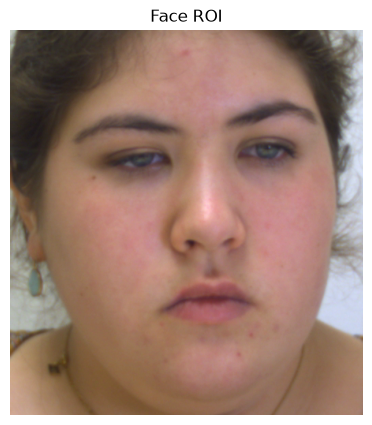

In [48]:
# Paths
video_path = Path("../data/raw/UBFC_Phys/s46/vid_s46_T1.avi")

# Read first frame
cap = cv2.VideoCapture(str(video_path))
ret, frame = cap.read()
cap.release()

# Face Detection
detector = FaceDetector()

results = detector.detect(frame)
face = detector.crop(frame, results)

# Display ROI (optional)
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Face ROI")
plt.show()

In [49]:
from stresscam.preprocessing.skin_segmentation import SkinSegmenter

segmenter = SkinSegmenter()

print(segmenter)

In [50]:
results = segmenter.detect_landmarks(face)

results.multi_face_landmarks

[landmark {
   x: 0.579769075
   y: 0.664411843
   z: -0.109586477
 }
 landmark {
   x: 0.58180207
   y: 0.549967825
   z: -0.188198552
 }
 landmark {
   x: 0.575183213
   y: 0.585712075
   z: -0.0999439955
 }
 landmark {
   x: 0.53989017
   y: 0.431937873
   z: -0.140003666
 }
 landmark {
   x: 0.580734968
   y: 0.513145089
   z: -0.19884944
 }
 landmark {
   x: 0.575426221
   y: 0.464559406
   z: -0.183028415
 }
 landmark {
   x: 0.55891341
   y: 0.348490715
   z: -0.0828049555
 }
 landmark {
   x: 0.295241654
   y: 0.352683365
   z: 0.0266967714
 }
 landmark {
   x: 0.551838517
   y: 0.270180225
   z: -0.0572951064
 }
 landmark {
   x: 0.550343096
   y: 0.22495538
   z: -0.0624241903
 }
 landmark {
   x: 0.535914838
   y: 0.0588108301
   z: -0.0112862503
 }
 landmark {
   x: 0.580325544
   y: 0.682021201
   z: -0.105546884
 }
 landmark {
   x: 0.579510152
   y: 0.695579171
   z: -0.0934641212
 }
 landmark {
   x: 0.577771127
   y: 0.70144546
   z: -0.0771033317
 }
 landmark {
   x: 

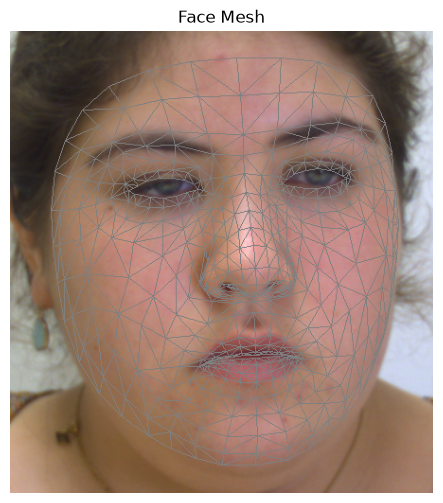

In [51]:
landmark_img = segmenter.draw_landmarks(face, results)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(landmark_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Face Mesh")
plt.show()

Text(0.5, 1.0, 'Face Mask')

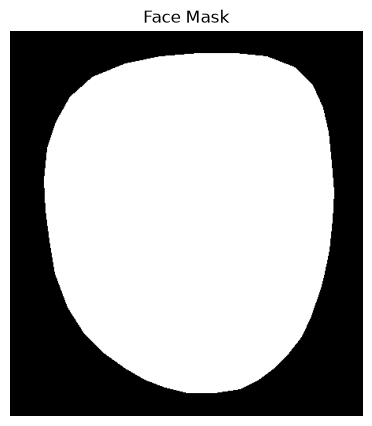

In [52]:
mask = segmenter.create_face_mask(face, results)

plt.figure(figsize=(5,5))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.title("Face Mask")

Text(0.5, 1.0, 'Masked Face')

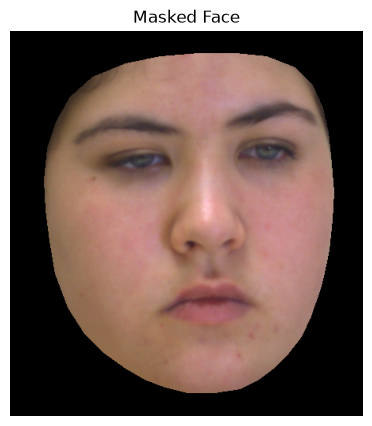

In [53]:
skin = segmenter.apply_mask(face, mask)

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(skin, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Masked Face")

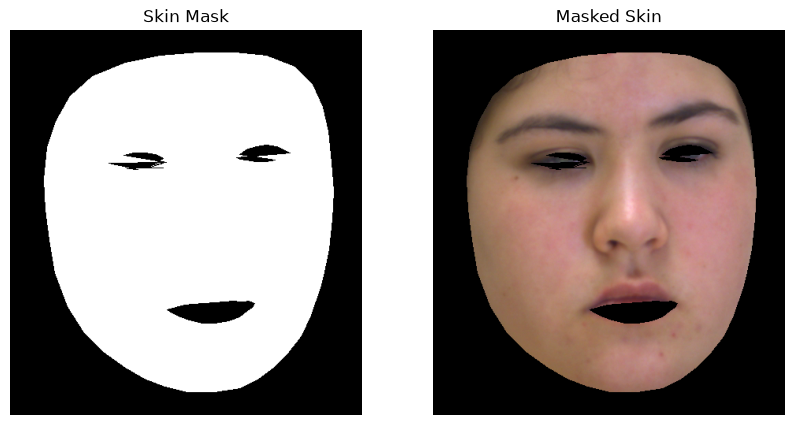

In [54]:
mask2 = segmenter.remove_features(mask.copy(), results)

skin = segmenter.apply_mask(face, mask2)

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(mask2, cmap="gray")
ax[0].set_title("Skin Mask")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(skin, cv2.COLOR_BGR2RGB))
ax[1].set_title("Masked Skin")
ax[1].axis("off")

plt.show()